.<center> 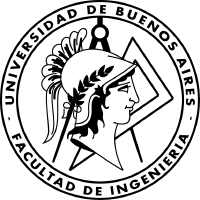



**Universidad de Buenos Aires**

**Facultad de Ingeniería**

**2do Cuatrimestre de 2025**

**Taller de Procesamiento de Señales**

---

**TP10: Gaussian Variational Bayes**

**Alumno:** Lo Coco, Manuel - mlococo@fi.uba.ar - 103938 </center>

---


## (a) Creación del dataset

Se generan 100 muestras de una mezcla de gaussianas con pesos 0.1, 0.4, 0.2, 0.3, medias -4, 0, 4, 5 y varianzas 1, 1.96, 1.44, 1 respectivamente. Estos datos pueden pensarse como 4 comportamientos distintos de los alumnos:


*   Un 10 % de personas muy puntuales
*   Un 40 % de personas que tienden a llegar justo
*   Un 20 % de personas “relajadas”
*   Un 30 % de personas consistentemente impuntuales

Como se puede ver, los pesos pueden considerarse como el porcentje de los alumos que pertenece a cada comportamiento, la media representa a que hora entra cada grupo a la clase de la facultad, en donde 0 es el horario justo, valore negativos son cuantos minutos antes llegaron y valores positivos cuanto minutos tarde llegaron. La varianza refleja la consistencia en su comportamiento.

Finalmente, se grafica el histograma de las muestras para poder ver el comportamiento.


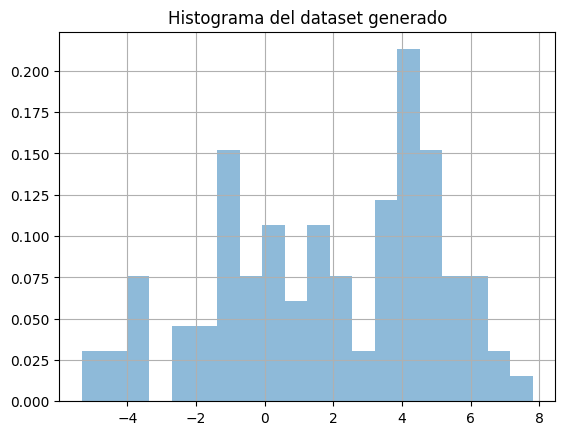

In [698]:
import numpy as np
import matplotlib.pyplot as plt

weights = [0.1, 0.4, 0.2, 0.3]
means   = [-4, 0, 4, 5]
vars    = [1, 1.96, 1.44, 1]

N=100
X = []

for w, mu, var in zip(weights, means, vars):
    n = int(N * w)
    X.append(np.random.normal(mu, np.sqrt(var), n))

X = np.concatenate(X)
np.random.shuffle(X)

# Graficar histograma
plt.hist(X, bins=20, density=True, alpha=0.5)
plt.title("Histograma del dataset generado")
plt.grid()
plt.show()




## (b) K-means

### (b.1)

Se define la clase Kmeans, que implementa el algoritmo de clustering para agrupar las muestras de tiempo de llegada en $K=6$ grupos de comportamiento. El método fit(X) inicializa los 6 centroides de manera aleatoria a partir de los datos y luego itera para asignar cada punto al centroide más cercano y recalcular los centroides. El entrenamiento utiliza una doble condición de parada: detiene el proceso si se alcanza el número máximo de iteraciones o si la convergencia se logra, es decir, si el movimiento de los centroides entre dos iteraciones es menor que la tolerancia especificada.

In [699]:
class Kmeans:
    # Inicializar atributos y declarar hiperparámetros
    def __init__(self, K=6, max_iter=200, tol=1e-4):
        self.K = K
        self.centroids = None
        self.labels    = None
        self.max_iter  = max_iter
        self.tol       = tol

    # Etapa de entrenamiento
    def fit(self,X):
        X = X.reshape(-1,1)
        n = len(X)
        index          = np.random.choice(n, self.K, replace=False)
        self.centroids = X[index]

        # corte por numero de iteraciones
        for _ in range(self.max_iter):

            distances      = np.abs(X - self.centroids.T)
            labels         = np.argmin(distances, axis=1)


            new_centroids = []
            for k in range(self.K):
                Xk = X[labels == k]

                if len(Xk) > 0:
                    new_centroids.append(np.mean(Xk))
                else:
                    new_centroids.append(self.centroids[k][0])

            new_centroids = np.array(new_centroids).reshape(-1, 1)

            # corte por convergencia
            if np.linalg.norm(new_centroids - self.centroids) < self.tol:
                break

            self.centroids = new_centroids

        self.labels = labels
        return self

    def predict(self, X_test):
        X_test = X_test.reshape(-1, 1)
        distances = np.abs(X_test - self.centroids.T)
        return np.argmin(distances, axis=1)

### (b.2)

Se extraen los resultados del clustering y se los utilizan como las estimaciones iniciales de Máxima Verosimilitud para los parámetros del modelo de mezcla de gaussianas: medias ($\mu_k$), varianzas ($\sigma^2_k$) y pesos ($\pi_k$).

In [700]:
K=6
kmeans = Kmeans(K=K, max_iter=200)
kmeans.fit(X)

mean_k = kmeans.centroids.flatten()
var_k = np.zeros(K)
weight_k = np.zeros(K)

for i in range(K):
    Xi = X[kmeans.labels == i]
    var_k[i] = np.var(Xi)
    weight_k[i] = len(Xi) / len(X)

print("Medias:", mean_k)
print("Varianzas:", var_k)
print("Pesos:", weight_k)

Medias: [ 3.8084961   6.34905074  4.78268735 -0.66456373 -3.69701768  1.71051196]
Varianzas: [0.09398257 0.47168916 0.11747344 0.44977671 0.77181474 0.33291878]
Pesos: [0.16 0.1  0.19 0.25 0.12 0.18]


### (b.3)

En primer lugar, se define la función matemática que modela la probabilidad de los tiempos de llegada y, luego se visualiza y compara la densidad de probabilidad real que generó los datos con la densidad estimada por el modelo K-means.

La Función de Densidad Gaussiana se define como:$$\mathcal{N}(x \mid \mu, \sigma^2) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp \left( - \frac{(x - \mu)^2}{2 \sigma^2} \right)$$

La densidad de probabilidad para la Mezcla de Gaussianas (GMM) se calcula sumando las contribuciones de todas las campanas, ponderadas por sus respectivos pesos ($\pi_k$):$$p(x) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(x \mid \mu_k, \sigma_k^2)$$

La densidad real se calcula usando los $K=4$ parámetros originales, mientras que la densidad Estimada se calcula usando los $K=6$ parámetros ($\pi_k, \mu_k, \sigma^2_k$) obtenidos por K-means.

En el gráfico final, se comparan estas dos curvas de densidad con el Histograma de los Datos ($X$). Es crucial entender que la curva de densidad es la suma de las 6 campanas. Por lo tanto, no se espera ver 6 picos separados. La cantidad de picos visibles está limitada por:

* Solapamiento: Si dos medias están muy cerca (como $\mu=4$ y $\mu=5$ en los datos reales), sus campanas se fusionan, creando un único pico ancho.

* Varianza: Las campanas con alta varianza son bajas y anchas, lo que tiende a "suavizar" la curva total, ocultando potencialmente los picos más pequeños.

El objetivo del gráfico es evaluar si la forma general de la densidad estimada por K-means logra aproximarse a la forma compleja de la densidad real, demostrando la capacidad del modelo para capturar la estructura de múltiples comportamientos.

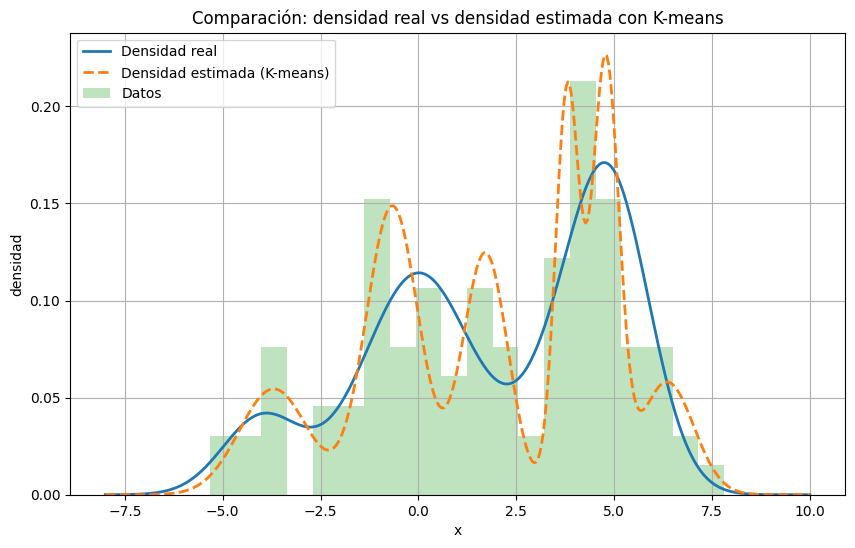

In [701]:
def normal_pdf(x, mu, var):
    return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-(x - mu)**2 / (2 * var))

xs = np.linspace(-8, 10, 400)

# calculo la densidad real
p_real = np.zeros_like(xs)
for w, mu, var in zip(weights, means, vars):
    p_real += w * normal_pdf(xs, mu, var)

# calculo la densidad estimada
p_kmeans = np.zeros_like(xs)
for w, mu, var in zip(weight_k, mean_k, var_k):
    p_kmeans += w * normal_pdf(xs, mu, var)

# grafico de densidad real, densidad estimada e histograma
plt.figure(figsize=(10,6))
plt.plot(xs, p_real, label="Densidad real", linewidth=2)
plt.plot(xs, p_kmeans, "--", label="Densidad estimada (K-means)", linewidth=2)
plt.hist(X, bins=20, density=True, alpha=0.3, label="Datos")

plt.legend()
plt.title("Comparación: densidad real vs densidad estimada con K-means")
plt.xlabel("x")
plt.ylabel("densidad")
plt.grid()
plt.show()


## (c) Expectation-Maximization

### (c.1)

Se implementa un algoritmo EM (Expectation-Maximization) para estimar de manera robusta los parámetros ($\pi_k, \mu_k, \sigma^2_k$) de la Mezcla de Gaussianas (GMM) con $K=6$ componentes. Se utiliza un esquema de inicialización robusto basado en K-means.

Este algoritmo itera entre los pasos de expectación y maximización hasta lograr una condición de parada que puede ser la convergencia o un número de iteraciones fijado.

* En el paso de expectación se calcula $\gamma_{ik}$ que es una matriz de probabilidades en donde se muestra la probabilidad de que un estudiante ($X_i$) pertenezca a un determinado comportamiento ($k$).

* En el paso de maximización se usa la mattriz $\gamma_{ik}$ para re-estimar los parámetros ($\pi_k, \mu_k, \sigma^2_k$).

In [702]:
class EM:
    def __init__(self, K=6, max_iter=100, tol=1e-4):
        self.K          = K
        self.max_iter   = max_iter
        self.tol        = tol
        self.mean_k     = None
        self.weight_k   = None
        self.var_k      = None

    def _gaussian_pdf(self, x, mu, var):
        var = np.maximum(var,1e-6)
        return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-(x - mu)**2 / (2 * var))

    def fit(self, X):
        X = X.reshape(-1, 1)
        N = len(X)

        # Inicializo con K means
        kmeans = Kmeans(self.K)
        kmeans.fit(X.flatten())
        labels = kmeans.labels

        self.mean_k   = kmeans.centroids.flatten()
        self.weight_k = np.zeros(self.K)
        self.var_k    = np.zeros(self.K)

        for k in range(self.K):
            Xk = X[labels == k]
            if len(Xk) == 0:
               self.weight_k[k] = 1.0 / self.K
               self.var_k[k]    = np.var(X) + 1e-9
            else:
               self.weight_k[k] = len(Xk) / N
               self.var_k[k]    = np.var(Xk) + 1e-9
        self.weight_k /= np.sum(self.weight_k)

        loglike_old = -np.inf


        for it in range(self.max_iter):
            # E-step
            weighted_pdfs = np.zeros((N, self.K))
            for k in range(self.K):
                pdf = self._gaussian_pdf(X, self.mean_k[k], self.var_k[k])
                weighted_pdfs[:, k] = self.weight_k[k] * pdf.flatten()

            p_x = np.sum(weighted_pdfs, axis=1, keepdims=True)
            gamma = weighted_pdfs / (p_x + 1e-9)

            loglike = np.sum(np.log(p_x + 1e-9))
            if loglike - loglike_old < self.tol:
                break
            loglike_old = loglike

            # M-step
            N_k = np.sum(gamma, axis=0)
            self.weight_k = N_k / N
            self.mean_k = np.sum(gamma * X, axis=0) / (N_k + 1e-9)

            for k in range(self.K):
                diff = X[:, 0] - self.mean_k[k]
                self.var_k[k] = np.sum(gamma[:, k] * diff**2) / (N_k[k] + 1e-9)

        return self

    def predict_proba(self, X):
        X = X.reshape(-1, 1)
        N = X.shape[0]
        weighted_pdfs = np.zeros((N, self.K))
        for k in range(self.K):
            pdf = self._gaussian_pdf(X, self.mean_k[k], self.var_k[k])
            weighted_pdfs[:, k] = self.weight_k[k] * pdf.flatten()

        p_x = np.sum(weighted_pdfs, axis=1, keepdims=True)
        gamma = weighted_pdfs / (p_x + 1e-9)
        return gamma

    def predict(self, X):
        gamma = self.predict_proba(X)
        return np.argmax(gamma, axis=1)

### (c.2)

Se grafica la densidad estimada por EM y se la compara con la estimación con Kmeans y la densidad real. Se logra observar que en EM al asignar las muestras de forma probabilística, generalmente logra un ajuste mucho más suave y preciso a la densidad real que el clustering duro de K-means.

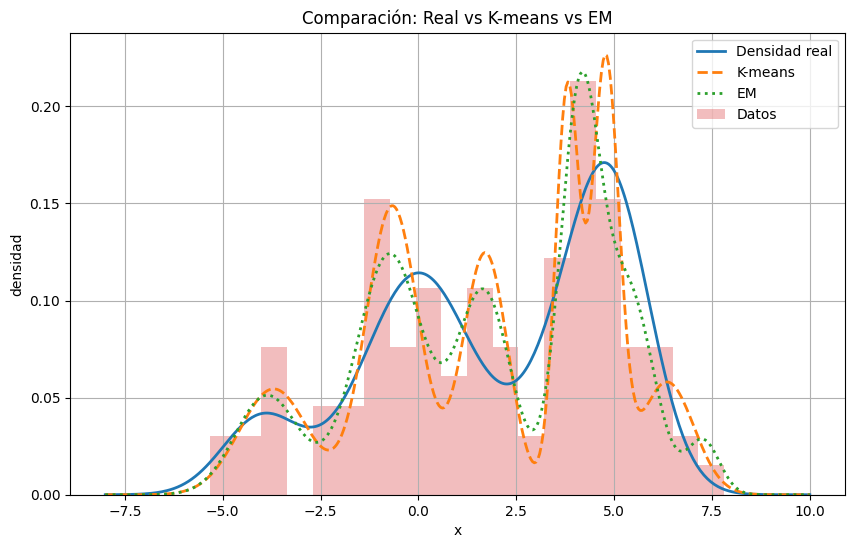

In [703]:
em_model = EM(K=6, max_iter=100, tol=1e-4)
em_model.fit(X)

p_em = np.zeros_like(xs)
for w, mu, var in zip(em_model.weight_k, em_model.mean_k, em_model.var_k):
    p_em += w * normal_pdf(xs, mu, var)

plt.figure(figsize=(10,6))

plt.plot(xs, p_real, label="Densidad real", linewidth=2)
plt.plot(xs, p_kmeans, "--", label="K-means", linewidth=2)
plt.plot(xs, p_em, ":", label="EM", linewidth=2)

plt.hist(X, bins=20, density=True, alpha=0.3, label="Datos")
plt.legend()
plt.title("Comparación: Real vs K-means vs EM")
plt.xlabel("x")
plt.ylabel("densidad")
plt.grid()
plt.show()

## (d) Gaussian Variational Bayes

### (d.1)


Se implementa la clase GVB (Gaussian Variational Bayes) para el problema de la Mezcla de Gaussianas Escalares utilizando el enfoque de Bayes Variacional (BV). Este método es una alternativa bayesiana al EM, donde en lugar de estimar un único conjunto de parámetros, se estima una distribución a posteriori sobre todos los parámetros del modelo ($\pi, \mu, \lambda$).

Interpretando su red bayesiana, la distribución del modelo puede escribirse como:

$$p(x,\mathbf{u},\pi,\lambda,\mu)=p(\pi)\Bigg(\prod_{k=1}^Kp(\lambda_k)p(\mu_k|\lambda_k)\Bigg)\Bigg(P(u_i|\pi)p(x_i|u_i,\mu,\lambda)\Bigg)$$

donde $u|\pi\sim\text{Cat}(\pi)$ y $x|u,\mu,\lambda\sim\mathcal{N}(\mu_u,\lambda_u^{-1})$. A priori supondremos distribuciones conjugadas a priori con verosimilitud:

$$\pi\sim\text{Dir}(\alpha) \ \ \ \ \lambda_k\sim\Gamma(\nu,\beta)\ \ \ \ \mu_k|\lambda_k\sim\mathcal{N}(m,(\delta \lambda_k)^{-1})$$

Los parámetros de este modelo serán entonces $\alpha, \nu, \delta, \beta$ y $m$.

Un vector aleatorio normal-gamma $(\nu, \beta, m, \delta)$ tiene una densidad conjunta de la forma:

$$p(\lambda,\mu)=\frac{\beta^{\nu}}{\Gamma(\nu)}\sqrt{\frac{\delta}{2\pi}}\lambda^{\nu-\frac{1}{2}}e^{-\lambda\big(\beta+\frac{\delta \mu^2}{2}-\delta m\mu+\frac{\delta m^2}{2}\big)}\mathbf{1}\{\lambda>0\}$$

Bajo la hipótesis de mean field approximation, $q(\mathbf{u},\pi,\lambda,\mu|x)=Q_1(\mathbf{u}|\mathbf{x})q_2(\pi,\lambda,\mu|\mathbf{x})$

En primer lugar, se considerará $Q_1$ fijo y conocido para computar $q_2$. Esto se conoce como actualización de los parámetros a posteriori.

Siendo $\gamma_{i,k}=Q_1(u_i=k|\mathbf{x})$, luego:

$$q_2(\pi,\lambda,\mu|\textbf{x}\propto p(\pi)\Bigg(\prod_{k=1}^K p(\lambda_k)p(\mu_k|\lambda_k)\Bigg)\prod_{k=1}^{K}e^{\sum_{i=1}^{n}\gamma_{i,k}[\log \pi_k+\log \mathcal{N}(x_i|\mu_k,\lambda_k^{-1})]}$$

y por lo tanto $q_2(\pi,\lambda,\mu|\mathbf{x})=q_2(\pi|\mathbf{x})\prod_{k=1}^{K}q_2(\mu_k,\lambda_k|\mathbf{x})$

En resumen,  la distribución a posteriori en un problema de GVB se calcula inicializando $\gamma_{i,k}$ (por ejemplo con el algoritmo EM) e iterando entre:

$$\alpha_k^*=\alpha_k+\sum_{i=1}^n\gamma_{i,k}\\
m_k^*=\frac{\delta m + \sum_{i=1}^n\gamma_{i,k}x_i}{\delta + \sum_{i=1}^n\gamma_{i,k}}\\
\delta_k^*=\delta+\sum_{i=1}^n\gamma_{i,k}\\
\nu_k^*=\nu+\frac{1}{2}\sum_{i=1}^n\gamma_{i,k}\\
\beta_k^*=\beta+\frac{\delta m^2}{2}+\frac{1}{2}\sum_{i=1}^n\gamma_{i,k}x_i^2-\frac{(\delta m +\sum_{i=1}^n\gamma_{i,k}x_i)^2}{2(\delta+\sum_{i=1}^n\gamma_{i,k})}
$$

Luego, se calcula $\gamma_{i,k}=\frac{\rho_{i,k}}{\sum_{c=1}^n\rho_{i,c}}$ a partir de $(\alpha^*,m_k^*,\delta_k^*,\nu_k^*,\beta_k^*)$ como:

$$\log\rho_{i,k}=\psi(\alpha_k^*)-\psi\Bigg(\sum_{c=1}^K\alpha_c^*\Bigg)+\frac{\psi(\nu_k^*)-\log(\beta_k^*)}{2}-\frac{1}{2\delta_k^*}-\frac{\nu_k^*}{2\beta_k^*}(m_k^*-x_i)^2$$

In [704]:
import numpy as np
from scipy.special import digamma, gamma, softmax

class GVB:
    def __init__(self, alpha, em_model, m=0, beta=0.05, delta=0.05, nu=0.05,
                 K=6, max_iter=100, tol=1e-4):
        self.K = K
        self.max_iter = max_iter
        self.tol = tol
        self.em = em_model

        # Parámetros a priori
        self.alpha = alpha
        self.m     = m
        self.delta = delta
        self.nu    = nu
        self.beta  = beta

        # Posteriores
        self.alpha_post = None
        self.m_post     = None
        self.delta_post = None
        self.nu_post    = None
        self.beta_post  = None
        self.gamma      = None


    def fit(self, X):
        X = X.reshape(-1,1)
        N = len(X)

        # Inicialización con EM
        self.gamma = self.em.predict_proba(X)

        # Inicializar posterior con prior
        self.alpha_post = self.alpha.copy()
        self.m_post     = np.full(self.K, self.m)
        self.delta_post = np.full(self.K, self.delta)
        self.nu_post    = np.full(self.K, self.nu)
        self.beta_post  = np.full(self.K, self.beta)

        for it in range(self.max_iter):

            gamma_old = self.gamma.copy()
            Nk = np.sum(self.gamma, axis=0)

            for k in range(self.K):
                self.alpha_post[k] = self.alpha[k] + Nk[k]
                num = self.delta * self.m + np.sum(self.gamma[:,k] * X[:,0])
                den = self.delta + Nk[k]

                self.m_post[k]     = num / den
                self.delta_post[k] = den
                self.nu_post[k]    = self.nu + 0.5 * Nk[k]

                sum_x2 = np.sum(self.gamma[:,k] * X[:,0]**2)
                self.beta_post[k] = (
                    self.beta
                    + 0.5*self.delta*self.m**2
                    + 0.5*sum_x2
                    - (num**2)/(2*den)
                )

            rho = np.zeros((N, self.K))

            for k in range(self.K):
                log_rho_k = (
                    digamma(self.alpha_post[k])
                    - digamma(np.sum(self.alpha_post))
                    + 0.5*(digamma(self.nu_post[k]) - np.log(self.beta_post[k]))
                    - 0.5*(1/self.delta_post[k])
                    - 0.5*(self.nu_post[k]/self.beta_post[k])*(X[:,0] - self.m_post[k])**2
                )
                rho[:,k] = np.exp(log_rho_k)

            self.gamma = rho / rho.sum(axis=1, keepdims=True)

            if np.max(np.abs(self.gamma - gamma_old)) < self.tol:
                break


    def predict_proba(self, X):
        return self.gamma


    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

### (d.2)

A partir de la distribución a posteriori se generan 3 muestras de parámetros y se grafica la densidad de $X|\mu,u,\pi$. Luego, se las compara con las densidades ya calculadas. Esta comparación permite observar la variabilidad inducida por la distribución a posteriori, así como evaluar qué tan bien la aproximación variacional captura la estructura real de la mezcla en relación con los métodos K-means y EM.

In [705]:
def mixture_density(xs, mu_k, lam_k, pi_k):
    f = np.zeros_like(xs)
    for mu, lam, pi in zip(mu_k, lam_k, pi_k):
        f += pi * normal_pdf(xs, mu, lam)
    return f

def sample_posterior_params(gvb, S=3):
    samples = []

    for _ in range(S):

        pi_sample = np.random.dirichlet(gvb.alpha_post)
        mu_sample = np.zeros(gvb.K)
        lambda_sample = np.zeros(gvb.K)

        for k in range(gvb.K):

            lambda_k = np.random.gamma(shape=gvb.delta_post[k],
                                    scale=1/gvb.beta_post[k])
            lambda_sample[k] = lambda_k
            var_mu = 1 / (gvb.delta_post[k] * lambda_k)
            mu_sample[k] = np.random.normal(gvb.m_post[k], np.sqrt(var_mu))
        samples.append((mu_sample, lambda_sample, pi_sample))

    return samples


In [706]:
gvb = GVB(K=6, em_model=em_model, alpha=np.ones(6))
gvb.fit(X)

labels = gvb.predict(X)
responsabilidades = gvb.predict_proba(X)
samples = sample_posterior_params(gvb, S=3)


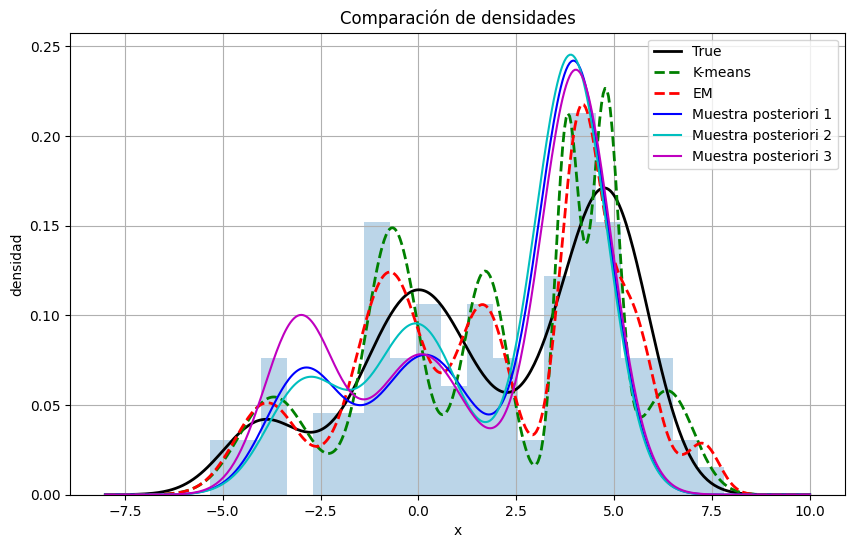

In [707]:
plt.figure(figsize=(10,6))

plt.plot(xs, p_real, "k", linewidth=2, label="True")
plt.plot(xs, p_kmeans, "g--", linewidth=2, label="K-means")
plt.plot(xs, p_em, "r--", linewidth=2, label="EM")

colors = ["b", "c", "m"]
for s, col, i in zip(samples, colors, [1,2,3]):
    mu_s, lam_s, pi_s = s
    p_post = mixture_density(xs, mu_s, lam_s, pi_s)
    plt.plot(xs, p_post, col, linewidth=1.5, label=f"Muestra posteriori {i}")

plt.hist(X, bins=20, density=True, alpha=0.3)
plt.title("Comparación de densidades")
plt.xlabel("x")
plt.ylabel("densidad")
plt.legend()
plt.grid()
plt.show()


### (d.3)

La densidad predictiva en el modelo GVB se escribe como:
$$
\begin{aligned}
p(x_{\text{test}}\mid D_n)
&= \sum_{k=1}^{K} w_k \; t\!\big(x_{\text{test}}\mid m_k^{*},\Lambda_k,\nu_k'\big), \\[6pt]
\quad
w_k &= \dfrac{\alpha_k^{*}}{\displaystyle\sum_{c=1}^{K}\alpha_c^{*}}, \\[6pt]
\Lambda_k &= \dfrac{\delta_k^{*}\,\nu_k^{*}}{(\delta_k^{*}+1)\,\beta_k^{*}}, \\[6pt]
\nu_k' &= 2\,\nu_k^{*}, \qquad m_k^{*}\
\end{aligned}
$$

donde la densidad t por componente es:

$$
\begin{aligned}
\quad
t(x\mid \mu,\Lambda,\nu)
&=
\dfrac{\Gamma\!\big(\tfrac{\nu+1}{2}\big)}
      {\Gamma\!\big(\tfrac{\nu}{2}\big)}
\sqrt{\dfrac{\Lambda}{\pi\,\nu}}\,
\Bigg(1+\dfrac{\Lambda\,(x-\mu)^2}{\nu}\Bigg)^{-\tfrac{\nu+1}{2}}
\end{aligned}
$$

En el gráfico se compara el histograma de los datos con cuatro densidades estimadas: la densidad verdadera del modelo generativo, la obtenida mediante K-means, la estimada por EM y la predictiva del modelo Variational Bayes Gaussiano (GVB).

La densidad verdadera no presenta cuatro picos claramente distinguibles, pese a que el modelo original tenía cuatro componentes. Esto se debe a que algunas de ellas se encuentran muy cercanas entre sí (especialmente las de media 4 y 5), mientras que otras poseen varianzas relativamente grandes. Como resultado, las componentes se solapan fuertemente, generando una forma multimodal suave pero sin modos completamente separados.

La densidad estimada mediante K-means muestra una aproximación irregular y con oscilaciones que no aparecen en la densidad verdadera. Esto ocurre porque K-means no ajusta un modelo probabilístico completo, sino que únicamente asigna clusters y luego estima medias y varianzas de manera rígida. Esto explica la presencia de picos artificiales y de una mayor variabilidad.

El algoritmo EM ofrece una aproximación más suave y estructurada. Reproduce razonablemente bien la forma general de la densidad verdadera, aunque tiende a generar picos más marcados —lo que indica un ajuste más rígido que puede acercarse al sobreajuste— especialmente en regiones donde la concentración de datos es mayor.

El modelo GVB produce una densidad más regularizada gracias a su naturaleza bayesiana. Su forma captura adecuadamente la estructura principal de los datos, manteniéndose cercana a la densidad verdadera pero sin picos excesivamente pronunciados. Esto refleja su capacidad para incorporar la incertidumbre en la estimación de parámetros, generando una curva más robusta y menos sensible al ruido.

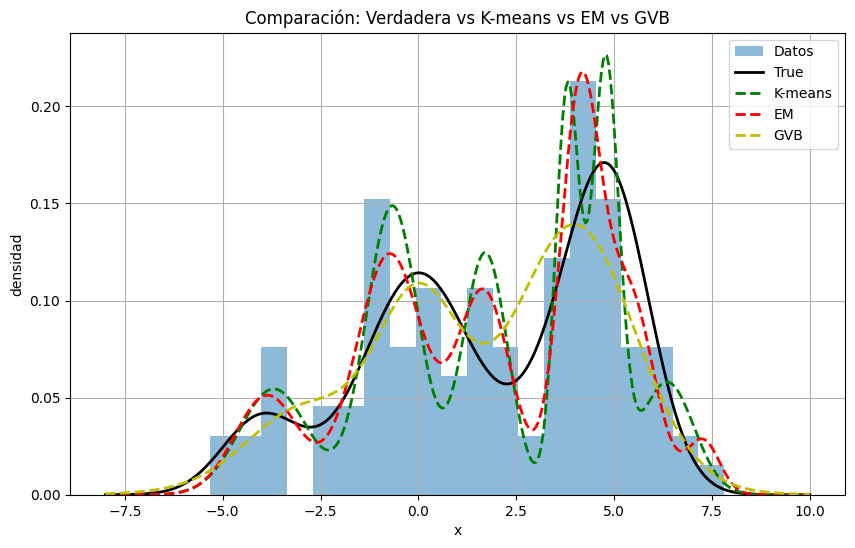

In [708]:
def t_student_pdf(x, mu, Lambda, nu):
    gamma_term = gamma((nu + 1) / 2) / (gamma(nu / 2) * np.sqrt(np.pi * nu / Lambda))
    power_term = (1 + (Lambda * (x - mu)**2) / nu)**(-(nu + 1) / 2)
    return gamma_term * power_term

def predictive_density_gvb(gvb, xs):
    xs = np.asarray(xs)
    p = np.zeros_like(xs, dtype=float)
    sum_alpha = np.sum(gvb.alpha_post)
    for k in range(gvb.K):
        nu = 2.0 * gvb.nu_post[k]
        Lambda_k = (gvb.delta_post[k] * gvb.nu_post[k]) / ((gvb.delta_post[k] + 1.0) * gvb.beta_post[k])
        weight_k = gvb.alpha_post[k] / sum_alpha
        p += weight_k * t_student_pdf(xs, gvb.m_post[k], Lambda_k, nu)
    return p


p_gvb = predictive_density_gvb(gvb, xs)

plt.figure(figsize=(10,6))
plt.hist(X, bins=20, density=True, alpha=0.5, label="Datos")
plt.plot(xs, p_real, "k", linewidth=2, label="True")
plt.plot(xs, p_kmeans, "g--", linewidth=2, label="K-means")
plt.plot(xs, p_em, "r--", linewidth=2, label="EM")
plt.plot(xs, p_gvb, "y--", linewidth=2, label = 'GVB' )
plt.title("Comparación: Verdadera vs K-means vs EM vs GVB")
plt.xlabel("x")
plt.ylabel("densidad")
plt.grid()
plt.legend()
plt.show()
